# 27 · Stress Testing: Historical Scenarios, Factor Shocks, and Correlation Breakdown

*Module 6 — Risk Management*

VaR and Expected Shortfall are built entirely from the distribution of returns you already have. Stress testing asks a deliberately different question: what happens to this exact portfolio if something the historical sample never quite showed actually happens?

## 1. Motivation

Notebook 26 built VaR and Expected Shortfall directly from a return sample's own statistical properties — and flagged, directly, why that is dangerous: a model built entirely from a calm historical window has no real basis for anticipating a regime it has never seen. Stress testing is the deliberate complement: instead of asking "what does history suggest is likely," it asks "if a specific, severe scenario occurred, what would happen to *this* portfolio, *today*" — a forward-looking, scenario-driven question a purely statistical model cannot answer on its own.

## 2. Intuition

Three genuinely different ways to stress a portfolio, each answering a different kind of "what if":

- **Historical scenarios** ask: "what if the *pattern* of returns from a known crisis period happened again, starting today, applied to my *current* holdings?" — replaying real, lived history rather than inventing a hypothetical one.
- **Factor shocks** ask: "what if a specific risk factor moved by a specific amount?" — a hypothetical, forward-looking, and fully controllable "what if the market fell 20%" or "what if rates rose 100 basis points," propagated through the portfolio's actual factor exposures (reusing Module 2's factor machinery directly).
- **Correlation stress** asks a subtler, and often-overlooked, question: what if the *relationships* between assets change, even if each asset's own volatility does not? This matters enormously because diversification — the entire premise behind holding a mix of assets in the first place — depends on correlations staying moderate. Correlations reliably rise during genuine crises (recall Notebook 19's copula discussion of tail dependence directly), and a stress test that only shocks individual asset levels while leaving correlations untouched can miss this entirely.

## 3. Theory

### 3.1 Historical scenario replay

Given a stylized shock vector $s\in\mathbb R^n$ (the return each asset experienced during some historical stress episode) and current portfolio weights $w$, the scenario's portfolio impact is simply

$$
\text{Impact} = w^\top s .
$$

The entire modeling burden sits in choosing $s$ realistically — the arithmetic afterward is trivial.

### 3.2 Factor shocks

Given a factor model $R_i = \sum_k \beta_{i,k}F_k + \varepsilon_i$ (exactly Notebook 9's setup) and a hypothetical shock to factor $k$, $\Delta F_k$, the implied shock to each asset is $\beta_{i,k}\Delta F_k$, and the portfolio impact is

$$
\text{Impact} = \sum_i w_i \sum_k \beta_{i,k}\Delta F_k = \sum_k \Delta F_k \Big(\sum_i w_i\beta_{i,k}\Big) = \sum_k \Delta F_k \, \beta_{p,k} ,
$$

where $\beta_{p,k}=\sum_i w_i\beta_{i,k}$ is the portfolio's own net exposure to factor $k$ — a direct, clean way to ask "how exposed am I, in aggregate, to a specific hypothetical shock," using exactly the same factor-loading machinery already built in Module 2.

### 3.3 Correlation stress

Portfolio variance is $\sigma_p^2=w^\top\Sigma w$, and $\Sigma = D\rho D$ for a diagonal matrix of volatilities $D$ and correlation matrix $\rho$. Crucially, individual asset volatilities can stay completely unchanged while $\sigma_p^2$ still rises sharply, purely because $\rho$ moves toward a more tightly-correlated stress state. A simple, standard way to model this: blend the normal correlation matrix toward a stress target,

$$
\rho_{\text{stress}} = (1-\lambda)\,\rho_{\text{normal}} + \lambda\, \rho_{\text{target}} ,
$$

where $\rho_{\text{target}}$ represents a "crisis" correlation structure (often a uniformly high correlation matrix, reflecting the empirical observation that in a genuine panic, nearly everything tends to sell off together, and idiosyncratic diversification benefits compress toward zero) and $\lambda\in[0,1]$ is the stress intensity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

## 4. Implementation

### 4.1 The same universe as Module 2, for direct continuity

In [2]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
NAMES = {'GALP': 'Galp Energia', 'EDP': 'EDP', 'JMT': 'Jeronimo Martins', 'BCP': 'Millennium bcp',
         'NOS': 'NOS', 'SEM': 'Semapa', 'SPY': 'S&P 500 ETF', 'IEF': '7-10yr US Treasury ETF'}
N = len(TICKERS)
TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])

corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30
    corr[i, 7] = corr[7, i] = -0.05
corr[6, 7] = corr[7, 6] = -0.10
Sigma = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)

w = np.ones(N) / N   # an equal-weight portfolio, for a clean illustration
port_vol_normal = np.sqrt(w @ Sigma @ w)
print(f"Portfolio annualized volatility under normal correlations: {port_vol_normal:.2%}")

Portfolio annualized volatility under normal correlations: 15.80%


### 4.2 Historical-style scenarios

**A methodological note:** the shock vectors below are stylized, illustrative approximations of the general *pattern* each named episode is widely understood to have produced (broad equity and credit weakness, a flight to government bonds) -- not verified, precise historical return data for these specific tickers. A production stress-testing framework would source actual historical returns for the exact instruments held; the mechanics demonstrated here are identical either way.

In [3]:
scenarios = {
    '2008-style credit crisis':  np.array([-0.45, -0.42, -0.30, -0.55, -0.35, -0.40, -0.38,  0.08]),
    'COVID-style crash':          np.array([-0.35, -0.30, -0.15, -0.40, -0.32, -0.28, -0.34,  0.05]),
    'Sharp rates-up shock':       np.array([-0.08, -0.10, -0.05, -0.12, -0.06, -0.07, -0.10, -0.09]),
}

rows = []
for name, shock in scenarios.items():
    rows.append({'scenario': name, 'portfolio impact': w @ shock})
pd.DataFrame(rows).round(4)

,scenario,portfolio impact
0,2008-style credit crisis,-0.3462
1,COVID-style crash,-0.2613
2,Sharp rates-up shock,-0.0837


### 4.3 A factor shock

In [4]:
# Illustrative betas to a single 'market' factor
betas = np.array([1.05, 0.95, 0.75, 1.15, 0.85, 1.10, 1.00, -0.05])
portfolio_beta = w @ betas
print(f"Portfolio net market beta: {portfolio_beta:.3f}")

for market_shock in [-0.10, -0.20, -0.35]:
    impact = portfolio_beta * market_shock
    print(f"  Market shock {market_shock:+.0%}  ->  portfolio impact {impact:+.2%}")

Portfolio net market beta: 0.850
  Market shock -10%  ->  portfolio impact -8.50%
  Market shock -20%  ->  portfolio impact -17.00%
  Market shock -35%  ->  portfolio impact -29.75%


### 4.4 Correlation stress, holding every individual volatility fixed

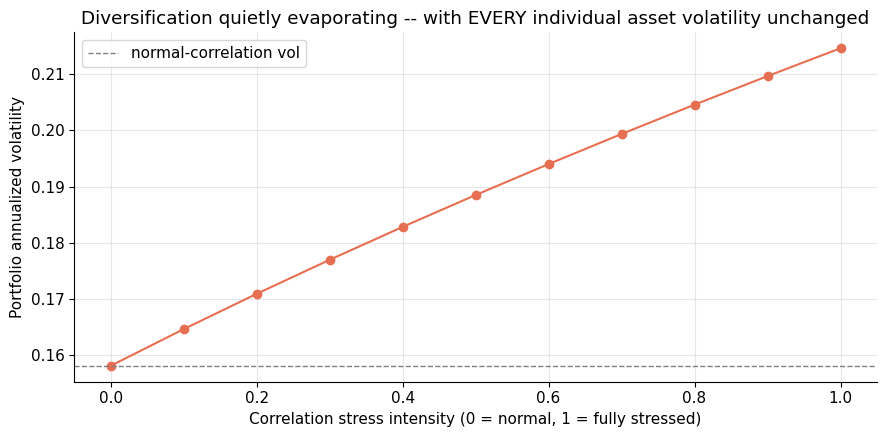

Portfolio vol rises from 15.80% to 21.47% (+36%) purely from correlations moving toward a stressed state.


In [5]:
def stress_correlation(corr, stress_level, target_corr=0.85):
    n = corr.shape[0]
    target = np.full((n, n), target_corr)
    np.fill_diagonal(target, 1.0)
    return (1 - stress_level) * corr + stress_level * target

stress_levels = np.linspace(0, 1, 11)
port_vols = []
for lam in stress_levels:
    corr_stressed = stress_correlation(corr, lam)
    Sigma_stressed = np.diag(TRUE_ANN_VOL) @ corr_stressed @ np.diag(TRUE_ANN_VOL)
    port_vols.append(np.sqrt(w @ Sigma_stressed @ w))

fig, ax = plt.subplots()
ax.plot(stress_levels, port_vols, marker='o', color='#e76f51')
ax.axhline(port_vol_normal, color='gray', linestyle='--', linewidth=1, label='normal-correlation vol')
ax.set_xlabel('Correlation stress intensity (0 = normal, 1 = fully stressed)')
ax.set_ylabel('Portfolio annualized volatility')
ax.set_title('Diversification quietly evaporating -- with EVERY individual asset volatility unchanged')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Portfolio vol rises from {port_vols[0]:.2%} to {port_vols[-1]:.2%} "
      f"({(port_vols[-1]/port_vols[0]-1):+.0%}) purely from correlations moving toward a stressed state.")

## 5. Worked example: a combined stress report

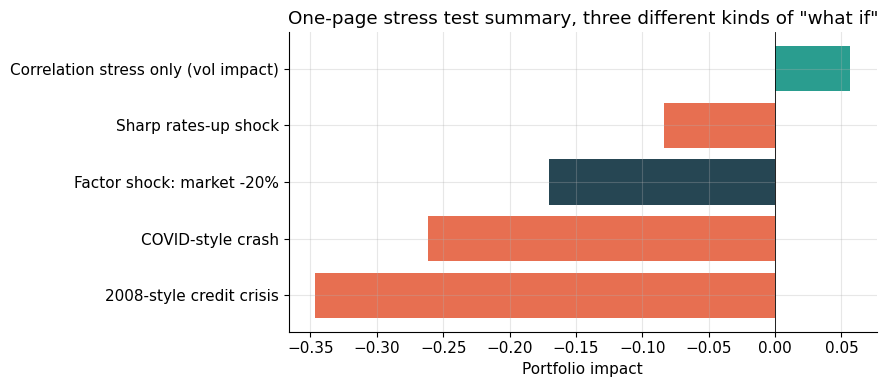

In [6]:
report = pd.DataFrame({
    'scenario': list(scenarios.keys()) + ['Factor shock: market -20%', 'Correlation stress only (vol impact)'],
    'type': ['Historical']*3 + ['Factor'] + ['Correlation'],
    'portfolio impact': [w @ s for s in scenarios.values()] + [portfolio_beta * -0.20, port_vols[-1] - port_vols[0]],
}).sort_values('portfolio impact')

fig, ax = plt.subplots(figsize=(9, 4))
colors = {'Historical': '#e76f51', 'Factor': '#264653', 'Correlation': '#2a9d8f'}
ax.barh(report['scenario'], report['portfolio impact'], color=[colors[t] for t in report['type']])
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Portfolio impact')
ax.set_title('One-page stress test summary, three different kinds of "what if"')
plt.tight_layout()
plt.show()

### Interpreting the result

None of these numbers come with a probability attached — that is a deliberate, structural feature of stress testing, not an omission. A 95% VaR tells you something is expected to happen roughly once every 20 periods; a stress scenario tells you "if this specific thing happens, here is the consequence for the book you actually hold today," with no claim about how likely that specific thing is. The two are complementary, not competing: VaR and Expected Shortfall summarize the *ordinary* distribution of outcomes efficiently; stress tests deliberately probe the scenarios a purely historical, statistical model has the least ability to anticipate on its own.

## 6. Limitations and pitfalls

- **Scenario selection is inescapably subjective.** There is no algorithm that generates "the right" set of stress scenarios — choosing which historical episodes, which factor shocks, and which magnitude of correlation stress to test is a judgment call, and a stress-testing framework is only as useful as the imagination (and institutional memory) behind its scenario selection.
- **Factor shocks are only as good as the underlying factor model.** If the true portfolio exposures are not well captured by the betas used (Module 2's whole estimation-error theme applies directly here too), the propagated impact will be systematically wrong even though the arithmetic itself is exact.
- **"Replaying" a historical scenario on today's portfolio silently assumes today's assets would react the same way they (or their historical analogues) did before** — a real assumption, not a neutral one, especially for instruments or relationships that did not exist, or behaved very differently, during the original episode.
- **Stress tests provide no probabilities, and cannot be combined additively into an overall risk number the way VaR-style measures can.** They tell you the consequence of specific, named scenarios — not how to weigh or prioritize among the infinite scenarios you did not think to test.
- **Correlation stress, as implemented here, is a simple linear blend toward an assumed target** — real crisis correlation dynamics are more structured and less uniform than this (recall Notebook 19's asymmetric, lower-tail-specific dependence from the Clayton copula), and a more sophisticated stress framework would model that asymmetry directly rather than blending toward a single uniform target correlation.

## 7. Exercises

**1. Your own scenario (warm-up).**
Design one additional historical-style scenario of your choosing (e.g., a sharp oil-price shock, disproportionately affecting `GALP`), assign a stylized shock vector across the 8 tickers reflecting your own reasoning about how each would respond, and add it to the `scenarios` dictionary. Where does it rank in the Section 5 summary chart?

**2. Which asset drives the most risk under each scenario type?**
For the '2008-style credit crisis' historical scenario and the market factor shock, decompose the total portfolio impact into each asset's individual contribution (`w[i] * shock[i]` for the historical case, `w[i] * beta[i] * market_shock` for the factor case). Which single asset contributes the most to portfolio losses in each case, and is it the same asset in both?

**3. Combining a factor shock WITH correlation stress.**
The factor-shock analysis in Section 4.3 used only average betas, implicitly holding correlations at their normal level. Build a combined scenario: shock the market factor by $-20\%$ *and* simultaneously stress correlations to `stress_level=0.6`, then compute the portfolio's expected loss *and* a stressed VaR (e.g., assume returns are approximately normal around the shocked mean, using the stressed covariance matrix from Section 4.4, and compute a 95% VaR under these combined stressed conditions). How much worse does the combined scenario look than either individual stress applied alone?